## 8 — Predict Individual IMD Deprivation Domains

This script:
- Reuses the data preparation from script 7 (per-LSOA per-cluster embeddings)
- Loads **all** IMD domain rank columns from the 2025 data
- For each domain × (each cluster + global), trains an XGBoost model (cloned from best_model) with 80/20 split
- Produces a results matrix (domains × clusters+global) and a heatmap

**TODO**: Currently uses domain **rank** as the target variable. Consider switching to domain **score** 
(requires File 1 from the IoD2025 release) and making this consistent across scripts 4, 7, and 8. 
Script 4 currently uses `imd_rerank` — this should also be made consistent.

### Dependencies
**Prerequisites:** Scripts 4 and 5 (needs best model and cluster-assigned pickle).

**Inputs:**
- `data/processed/one_row_per_image_cleaned_with_cluster_numbers.pkl` — from script 5
- `data/models/best_model.joblib` — from script 4 (cloned for per-domain models)
- IMD Excel file (via `imd_file`) — all 8 domain rank columns
- `clustering_functions.py` — imports `global_k`, `RANDOM_STATE`, `embedding_statistic`, `agg_funcs`

**Outputs:**
- No saved files (results computed in memory); displays R² and NRMSE heatmaps

**Used by:** None (terminal analysis notebook)

In [1]:
import os
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone  # clone lets us re-use the best model's architecture without leaking fitted state
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
from directory_filepaths import *
from clustering_functions import global_k, RANDOM_STATE, embedding_statistic, mean_embed, median_embed, max_embed, agg_funcs

# global_k is the number of clusters (set once in clustering_functions.py, used across all scripts)
print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Using '{embedding_statistic}' embedding aggregation (from clustering_functions.py)")
k = global_k

In [ ]:
# ---- Configuration ----

# Aggregation statistic is defined centrally in clustering_functions.py
statistic = embedding_statistic

### Load image data and compute per-LSOA embeddings
Same approach as script 7.

In [4]:
# Load the expanded dataframe with cluster assignments (output of script 5).
# This has one row per image (~75k rows), each with a 512-dim CLIP embedding
# and a cluster label (e.g. scene_cluster_5 = 1..5).
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned_with_cluster_numbers.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")

Loaded 75586 image rows


In [5]:
# The cluster column name depends on k (e.g. "scene_cluster_5" for k=5)
category_column = f"scene_cluster_{k}"
categories = sorted(expanded_gdf[category_column].unique())
print(f"Clusters: {categories}")

Clusters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


In [ ]:
# --- Aggregate image-level embeddings to per-LSOA summaries ---
# For each LSOA, we compute three summary statistics (mean, median, max)
# of the 512-dim embeddings, both:
#   (a) within each cluster separately (e.g. "1_median", "2_median", ...)
#   (b) across all images regardless of cluster ("overall_median")
# This gives us the feature vectors we'll use as model inputs.
#
# mean_embed, median_embed, max_embed, and agg_funcs are imported from clustering_functions.py

all_dfs = []
for agg_name, func in agg_funcs.items():
    dfs = []

    # Per-cluster: aggregate embeddings for images in each cluster within each LSOA
    for cat in categories:
        emb_cat = (
            expanded_gdf[expanded_gdf[category_column] == cat]
            .groupby("LSOA21CD")["embedding"]
            .apply(func)
            .reset_index()
            .rename(columns={"embedding": f"{cat}_{agg_name}"})
        )
        dfs.append(emb_cat)

    # Outer merge so LSOAs missing a cluster get NaN (handled later)
    # (reduce() cumulatively merges the dfs)
    merged = reduce(lambda left, right: pd.merge(left, right, on="LSOA21CD", how="outer"), dfs)

    # Overall: aggregate across ALL images in the LSOA (ignoring cluster)
    overall = (
        expanded_gdf.groupby("LSOA21CD")["embedding"]
        .apply(func)
        .reset_index()
        .rename(columns={"embedding": f"overall_{agg_name}"})
    )
    merged = merged.merge(overall, on="LSOA21CD", how="left")
    all_dfs.append(merged)

# Combine mean, max, and median into a single wide DataFrame
# Result: one row per LSOA, columns like "1_mean", "1_median", ..., "overall_median", etc.
embedding_df = reduce(lambda left, right: pd.merge(left, right, on="LSOA21CD", how="outer"), all_dfs)
print(f"{len(embedding_df)} LSOAs, {len(embedding_df.columns) - 1} embedding columns")

In [7]:
embedding_df

,LSOA21CD,1_mean,2_mean,3_mean,4_mean,5_mean,overall_mean,1_max,2_max,3_max,4_max,5_max,overall_max,1_median,2_median,3_median,4_median,5_median,overall_median
0,E01004766,"[0.029265722, -0.07180277, 0.001431624, -0.002...","[0.028140508, -0.05481386, -0.0025622249, -0.0...","[0.031188201, -0.057373047, -0.014732361, -0.0...","[0.033780266, -0.0537989, 0.01596535, -0.00700...","[0.043642044, -0.061961364, -0.0028877258, -0....","[0.03482639, -0.058570504, 0.0016810745, -0.00...","[0.05166626, -0.04244995, 0.020477295, 0.01791...","[0.057159424, -0.014503479, 0.017410278, 0.014...","[0.06604004, -0.025939941, 0.011779785, 0.0054...","[0.06878662, 0.02444458, 0.04058838, 0.0209045...","[0.06555176, -0.036071777, 0.027816772, 0.0227...","[0.06878662, 0.02444458, 0.04058838, 0.0227813...","[0.0313797, -0.07397461, -0.0011296272, -0.006...","[0.032463074, -0.05130005, 0.002090454, -0.008...","[0.032989502, -0.055511475, -0.018936157, 4.17...","[0.027740479, -0.06121826, 0.015533447, -0.007...","[0.045806885, -0.060012817, -0.00081825256, -0...","[0.037399292, -0.060531616, 0.0037984848, -0.0..."
1,E01004767,"[0.016731381, -0.06825256, -0.0067703724, 0.00...","[0.034693144, -0.053133108, -0.008565903, -0.0...","[0.028606415, -0.06138611, -0.023513794, 0.010...","[0.031008562, -0.05026579, 0.013707082, -0.008...","[0.040097427, -0.06577148, -0.0054997443, -0.0...","[0.031465285, -0.058895655, -0.0012362666, -0....","[0.04421997, -0.03491211, 0.0115737915, 0.0414...","[0.061798096, 0.0012311935, 0.020095825, 0.005...","[0.05206299, -0.046447754, -0.003540039, 0.024...","[0.0647583, 0.007045746, 0.057800293, 0.018951...","[0.07910156, -0.040283203, 0.022415161, 0.0113...","[0.07910156, 0.007045746, 0.057800293, 0.04144...","[0.017009735, -0.064971924, -0.0054035187, -0....","[0.029327393, -0.057861328, -0.0075244904, -0....","[0.024368286, -0.049316406, -0.021812439, 0.00...","[0.027359009, -0.050628662, 0.011787415, -0.00...","[0.037857056, -0.05973816, -0.0067977905, -0.0...","[0.028137207, -0.05706787, -0.002474308, -0.00..."
2,E01004768,"[0.036216736, -0.06918335, -0.0037015914, 0.00...",NaN,"[0.052099373, -0.061589167, -0.014418822, 0.00...","[0.028550042, -0.05822076, 0.018985748, -0.016...","[0.037856158, -0.0654997, 0.001209259, -0.0159...","[0.03997456, -0.06327403, -0.0003300797, -0.00...","[0.06744385, -0.029022217, 0.009536743, 0.0340...",NaN,"[0.08831787, -0.042388916, 0.014816284, 0.0141...","[0.066711426, -0.04043579, 0.035186768, 0.0102...","[0.059661865, -0.04296875, 0.03161621, 0.00774...","[0.08831787, -0.029022217, 0.035186768, 0.0340...","[0.034729004, -0.072265625, -0.007358551, -0.0...",NaN,"[0.048187256, -0.055847168, -0.017730713, 0.00...","[0.025375366, -0.060943604, 0.022583008, -0.01...","[0.03591919, -0.06744385, -0.0029392242, -0.01...","[0.036331177, -0.06199646, -0.0030584335, -0.0..."
3,E01004769,"[0.032989502, -0.056932237, -0.01499388, -0.00...","[0.044647217, -0.0690918, -0.009788513, 0.0082...","[0.048132323, -0.049468994, -0.02563095, -0.00...","[0.047772724, -0.07256063, 0.012763977, -0.014...","[0.031168802, -0.06304496, -0.005654335, -0.00...","[0.038646888, -0.059854127, -0.0100904945, -0....","[0.045013428, -0.041870117, 4.9591064e-05, 0.0...","[0.044647217, -0.0690918, -0.009788513, 0.0082...","[0.059020996, -0.026062012, -0.011787415, 0.00...","[0.07623291, -0.04095459, 0.017303467, -0.0046...","[0.059448242, -0.03744507, 0.024093628, 0.0186...","[0.07623291, -0.026062012, 0.024093628, 0.0186...","[0.031921387, -0.059783936, -0.013145447, -0.0...","[0.044647217, -0.0690918, -0.009788513, 0.0082...","[0.047332764, -0.048706055, -0.02584076, -0.00...","[0.04798889, -0.0769043, 0.014221191, -0.01444...","[0.028778076, -0.06552124, -0.0062408447, -0.0...","[0.039871216, -0.058303833, -0.011016846, -0.0..."
4,E01004770,"[0.01990954, -0.050582886, -0.0036970775, 0.00...","[0.028320312, -0.053863525, -0.0098724365, -0....","[0.02395303, -0.065194264, -0.016976492, 0.004...","[0.031389713, -0.060276

### Load IMD domain data

In [8]:
# Load the full IMD 2025 domains spreadsheet
imd = pd.read_excel(imd_file, sheet_name="IoD2025 Domains", header=0)
imd = imd.rename(columns={"LSOA code (2021)": "LSOA21CD"})

# Map short domain names -> full column names in the spreadsheet.
# This dict is the single place to edit if switching from rank to score columns.
imd_domains = {
    "Income":             "Income Rank (where 1 is most deprived)",
    "Employment":         "Employment Rank (where 1 is most deprived)",
    "Education":          "Education, Skills and Training Rank (where 1 is most deprived)",
    "Health":             "Health Deprivation and Disability Rank (where 1 is most deprived)",
    "Crime":              "Crime Rank (where 1 is most deprived)",
    "Housing":            "Barriers to Housing and Services Rank (where 1 is most deprived)",
    "Living Environment": "Living Environment Rank (where 1 is most deprived)",
}

# Include overall IMD as an extra row so we can compare domain-level vs overall prediction
imd_domains["IMD (overall)"] = "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)"

# Keep only the columns we need (LSOA code + one rank column per domain)
imd_cols = ["LSOA21CD"] + list(imd_domains.values())
imd = imd[imd_cols]

print(f"Loaded IMD data for {len(imd)} LSOAs, {len(imd_domains)} domains")

Loaded IMD data for 33755 LSOAs, 8 domains


In [9]:
# Inner merge: keep only LSOAs that have both embedding data and IMD data
df = embedding_df.merge(imd, on="LSOA21CD")
print(f"{len(df)} LSOAs after merge")

1695 LSOAs after merge


### Load best model

In [10]:
# Load the best model found in script 4 (a Pipeline: StandardScaler -> XGBRegressor).
# We'll clone() this for each (domain, cluster) combination so each model starts fresh.
best_model = joblib.load(os.path.join("../data/models/best_model.joblib"))['model']

### Train models: each domain × (each cluster + global)

For each domain, train a separate model for:
- Each cluster (using that cluster's median embedding; LSOAs without images in that cluster are dropped)
- Global (using the overall median embedding across all clusters; all LSOAs included)

#### Why NRMSE?

Raw R² and RMSE are **not directly comparable** across clusters because each cluster model is 
evaluated on a different subset of LSOAs (different sizes, different deprivation distributions).

**Normalised RMSE** (NRMSE = RMSE / std(y_test)) removes this confound by expressing the 
prediction error relative to the target's spread in each test set. An NRMSE of 1.0 means the 
model is no better than predicting the mean; lower is better. Because NRMSE is unitless and 
scale-free, it can be compared across clusters and across domains.

In [11]:
# Results storage: nested dict {domain_name: {column_label: {"R2": ..., "RMSE": ..., "NRMSE": ...}}}
all_results = {}

for domain_name, domain_col in imd_domains.items():
    domain_results = {}

    # --- Per-cluster models ---
    # For each cluster, use only that cluster's median embedding as features.
    # Not every LSOA will have images in every cluster, so we drop those.
    for cluster_num in categories:
        emb_col = f"{cluster_num}_{statistic}"  # e.g. "1_median"

        subset = df[["LSOA21CD", emb_col, domain_col]].copy()
        n_before = len(subset)

        # Drop LSOAs where this cluster has no images.
        # When a cluster has no images in an LSOA, the outer merge left a NaN scalar
        # (rather than a 512-dim array), so we detect that here.
        has_embedding = subset[emb_col].apply(lambda x: not (isinstance(x, float) and np.isnan(x)))
        subset = subset[has_embedding].reset_index(drop=True)
        n_dropped = n_before - len(subset)

        if n_dropped > 0:
            print(f"  {domain_name} | Cluster {cluster_num}: dropped {n_dropped} LSOAs "
                  f"with no images in this cluster ({len(subset)} remaining)")

        # Build feature matrix: stack the 512-dim embeddings into a (n_lsoas, 512) array
        X = np.stack(subset[emb_col].values)
        y = subset[domain_col].values

        # 80/20 train-test split (same random state as other scripts for consistency)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE)

        # Clone creates an unfitted copy of the pipeline with the same hyperparameters
        model = clone(best_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        domain_results[f"Cluster {cluster_num}"] = {
            "R2": r2_score(y_test, y_pred),
            "RMSE": rmse,
            "NRMSE": rmse / np.std(y_test),  # normalised by test set std dev
        }

    # --- Global model ---
    # Uses the overall median embedding (aggregated across ALL images in the LSOA,
    # regardless of cluster). All LSOAs are included (no drops).
    emb_col_global = f"overall_{statistic}"
    X_global = np.stack(df[emb_col_global].values)
    y_global = df[domain_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_global, y_global, test_size=0.2, random_state=RANDOM_STATE)

    model = clone(best_model)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    domain_results["Global"] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": rmse,
        "NRMSE": rmse / np.std(y_test),
    }

    all_results[domain_name] = domain_results

print("\nDone.")

  Income | Cluster 1: dropped 270 LSOAs with no images in this cluster (1425 remaining)
  Income | Cluster 2: dropped 150 LSOAs with no images in this cluster (1545 remaining)
  Income | Cluster 3: dropped 585 LSOAs with no images in this cluster (1110 remaining)
  Income | Cluster 4: dropped 29 LSOAs with no images in this cluster (1666 remaining)
  Income | Cluster 5: dropped 45 LSOAs with no images in this cluster (1650 remaining)
  Employment | Cluster 1: dropped 270 LSOAs with no images in this cluster (1425 remaining)
  Employment | Cluster 2: dropped 150 LSOAs with no images in this cluster (1545 remaining)
  Employment | Cluster 3: dropped 585 LSOAs with no images in this cluster (1110 remaining)
  Employment | Cluster 4: dropped 29 LSOAs with no images in this cluster (1666 remaining)
  Employment | Cluster 5: dropped 45 LSOAs with no images in this cluster (1650 remaining)
  Education | Cluster 1: dropped 270 LSOAs with no images in this cluster (1425 remaining)
  Education |

### Results matrix

In [12]:
# Build results matrices for both metrics.
# Rows = IMD domains, Columns = clusters + Global.
cluster_cols = [f"Cluster {c}" for c in categories]
col_order = cluster_cols + ["Global"]

r2_matrix = pd.DataFrame(
    {domain: {col: metrics["R2"] for col, metrics in cols.items()}
     for domain, cols in all_results.items()}
).T[col_order]

nrmse_matrix = pd.DataFrame(
    {domain: {col: metrics["NRMSE"] for col, metrics in cols.items()}
     for domain, cols in all_results.items()}
).T[col_order]

print("R² (higher = better, but not comparable across clusters):")
r2_matrix

R² (higher = better, but not comparable across clusters):


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Global
Income,0.312947,0.311647,0.032321,0.574426,0.535081,0.642554
Employment,0.288597,0.304505,0.086697,0.543175,0.514815,0.634836
Education,0.312899,0.347507,0.080244,0.584004,0.544841,0.680440
Health,0.362896,0.366377,0.177666,0.574508,0.557709,0.673777
Crime,0.268942,0.322693,0.088792,0.476873,0.447629,0.569632
Housing,0.209116,0.140660,0.046642,0.328937,0.245099,0.441674
Living Environment,0.064207,0.199949,-0.016698,0.517745,0.458733,0.632252
IMD (overall),0.321291,0.367246,0.064740,0.599200,0.565308,0.680759


In [13]:
print("NRMSE (lower = better, comparable across clusters):")
nrmse_matrix

NRMSE (lower = better, comparable across clusters):


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Global
Income,0.828886,0.829671,0.983707,0.652360,0.681850,0.597868
Employment,0.843447,0.833963,0.955669,0.675888,0.696552,0.604288
Education,0.828915,0.807770,0.959039,0.644978,0.674655,0.565296
Health,0.798188,0.796004,0.906826,0.652297,0.665049,0.571159
Crime,0.855019,0.822987,0.954572,0.723275,0.743217,0.656025
Housing,0.889317,0.927006,0.976401,0.819184,0.868850,0.747212
Living Environment,0.967364,0.894456,1.008314,0.694446,0.735708,0.606422
IMD (overall),0.823838,0.795459,0.967088,0.633087,0.659311,0.565014


### Heatmap

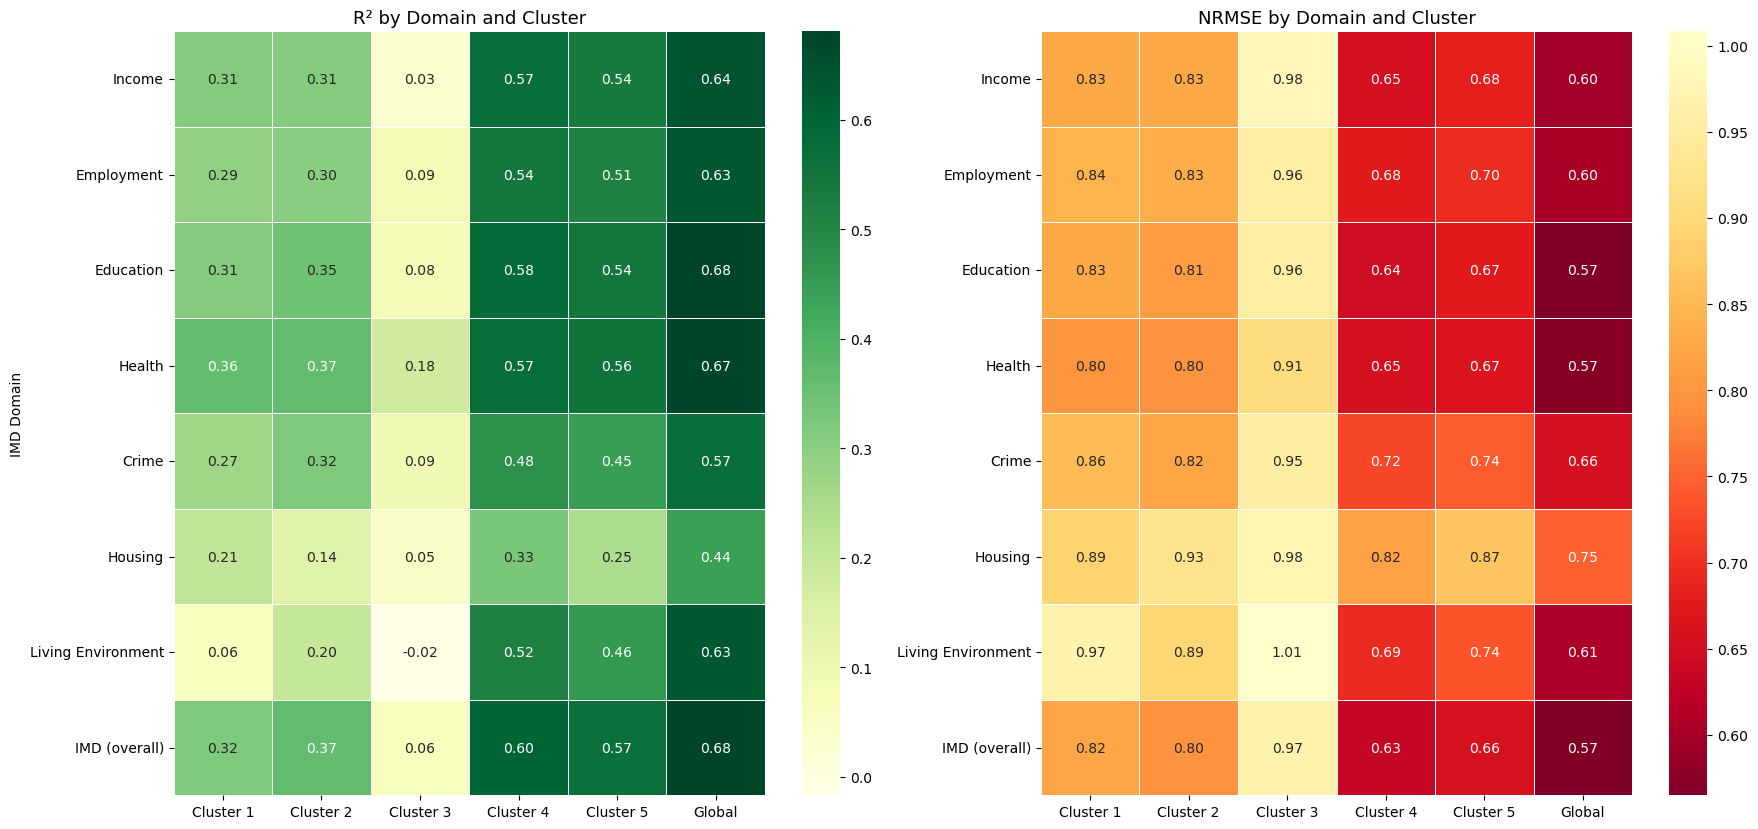

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(max(14, len(col_order) * 3), len(r2_matrix) * 0.8 + 2))

# --- Left: R² heatmap (higher = better) ---
sns.heatmap(
    r2_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("R² by Domain and Cluster", fontsize=13)
axes[0].set_ylabel("IMD Domain")
axes[0].set_xlabel("")

# --- Right: NRMSE heatmap (lower = better, comparable across clusters) ---
sns.heatmap(
    nrmse_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("NRMSE by Domain and Cluster", fontsize=13)
axes[1].set_ylabel("")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()